In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [3]:
sns.set_style('whitegrid')
%matplotlib inline

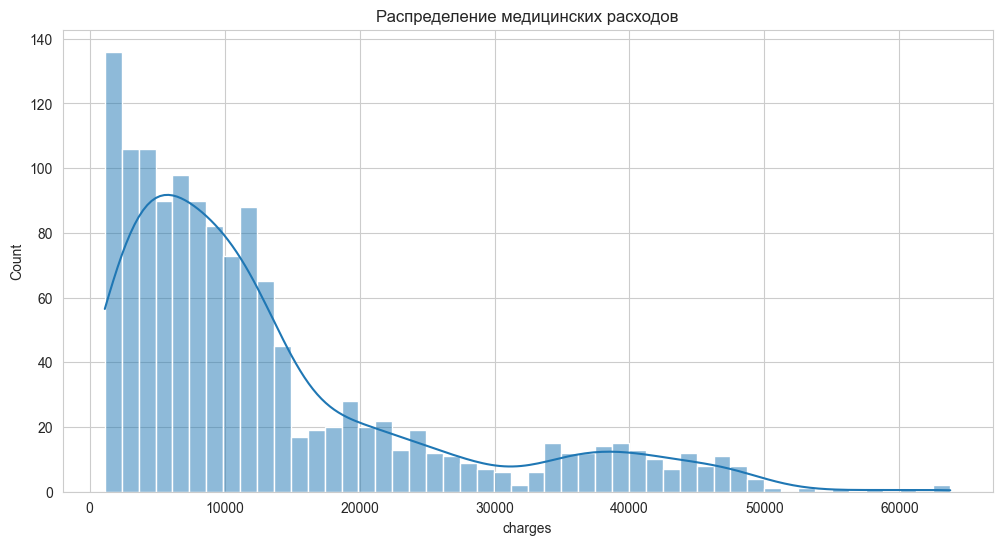

In [6]:
plt.figure(figsize=(12,6))
sns.histplot(df['charges'], bins=50, kde=True)
plt.title("Распределение медицинских расходов")
plt.show()

График скошен вправо и данные не распределены нормально, что говорит о том, что большинство людей имеют небольшие медицинские расходы. KDE имеет волны, самый большой пик находиться в районе 5000-7000, второй пик в  районе 40000. Это может быть каким то скрытым фактором.

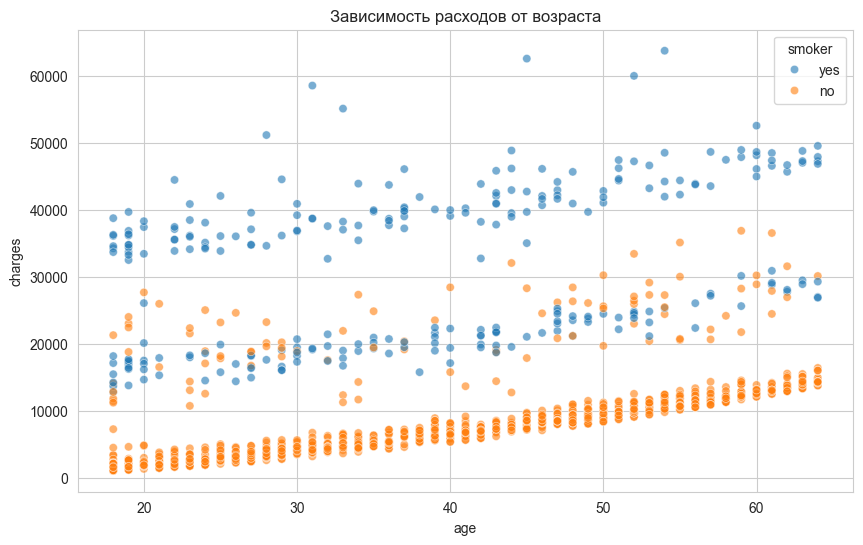

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df, alpha=0.6, hue='smoker')
plt.title("Зависимость расходов от возраста")
plt.show()

Данные разделились на три кластера, что значит что здесь есть категориальный признак, и самый возможный признак это курение. Чтобы убедиться в этом, добавим hue='smoker', и дальше уже видим что нижняя линия это здоровые, некурящие люди и соответственно их медицинские расходы меньше, чем у остальных. Чтобы определить среднюю и верхнюю линию, добавим еще параметр BMI:

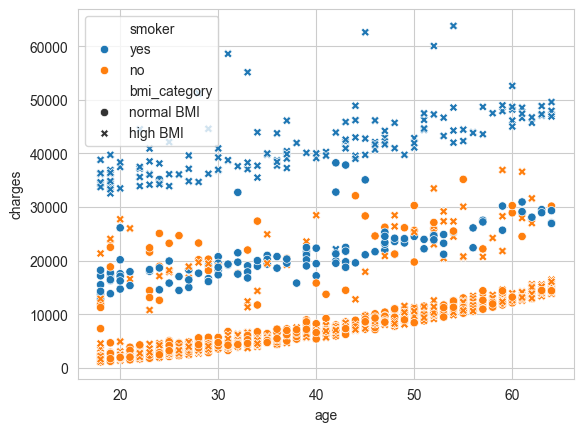

In [11]:
df['bmi_category'] = df['bmi'].apply(lambda x: 'high BMI' if x >= 30 else 'normal BMI')
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', style='bmi_category')
plt.show()

Мы видим что верхняя линия это комбинация высоко BMI и курения.

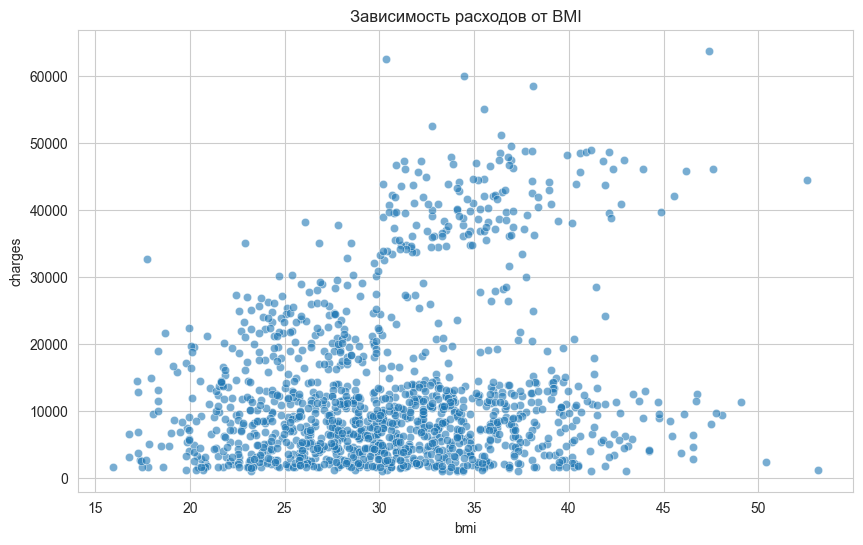

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6)
plt.title("Зависимость расходов от BMI")
plt.show()

Здесь после ВМІ іқ мы видим облако в верхней части графика, что может быть курящими людьми с ожирением.Можно сказать если ты куришь и твой BMI превышает 30, твои медицинские расходы взлетают экспоненциально.

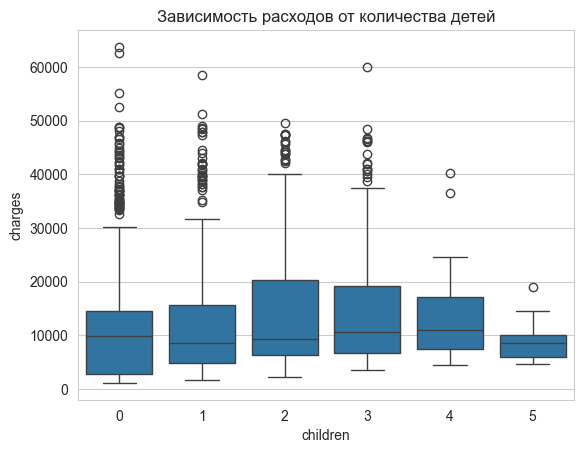

In [9]:
sns.boxplot(x='children', y='charges', data=df)
plt.title("Зависимость расходов от количества детей")
plt.show()

Медиана примерно одинаковая, наличие детей вляет на расходы незначительно. Но мы видим что у тех, у кого пять детей расходы меньше. Это может быть из за того, что в датасете людей с 5 детьми. Верхняя граница ящика у людей с 2-3 детьми чуть выше, чем у группы 0 детей. Больше членов семьи в одном полисе значит выше вероятность медицинских обращений.

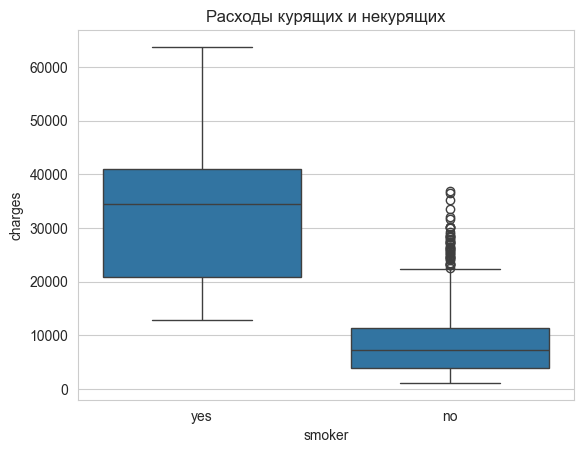

In [12]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Расходы курящих и некурящих")
plt.show()

Смотря на медианы, можно сказать что средний чек курильщика в 3.5–4 раза выше. Размер ящика у курильщик огромный, что значит их расходы очень разные. Точки над правым ящиком могут означать редкие случаи как редкие заболевания, серьезные травмы и тд.

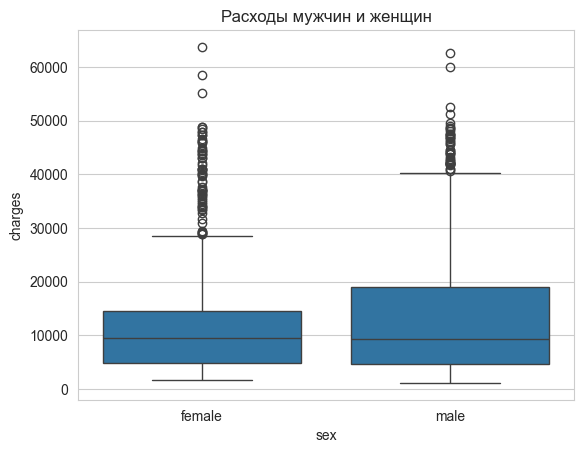

In [13]:
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Расходы мужчин и женщин')
plt.show()

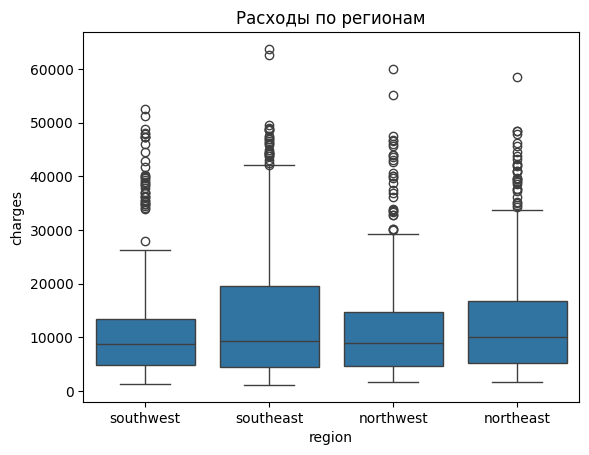

In [7]:
sns.boxplot(x='region', y='charges', data=df)
plt.title('Расходы по регионам')
plt.show()

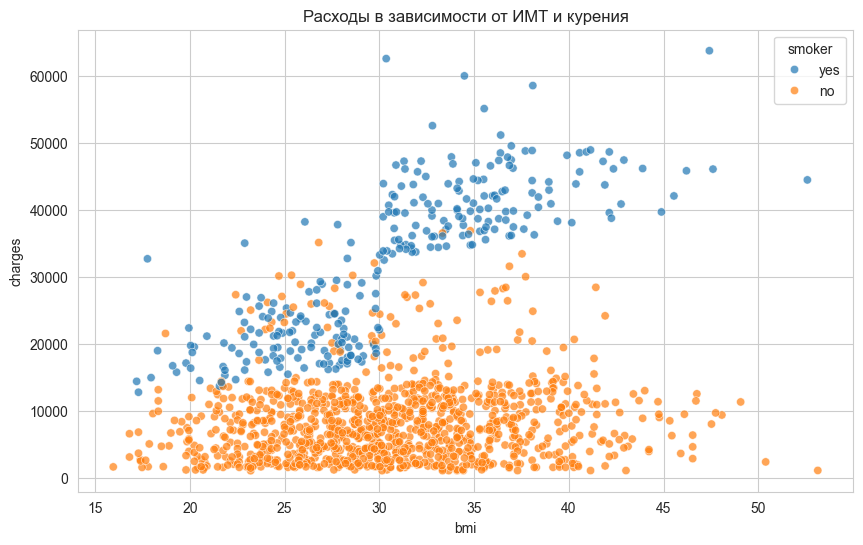

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title('Расходы в зависимости от ИМТ и курения')
plt.show()

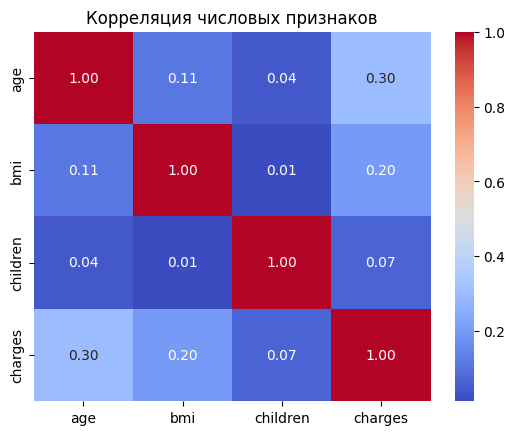

In [4]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

Видим, что возраст имеет самую сильную связь из данных признаков, то есть с возрастом расходы растут. ВМІ показывает слабую связь,  это может быть из за того что корреляция Пирсоны плохо ловит такие нелинейные связи,  что мы видели в графике с ВМІ. А наличие детей практически не помогает предсказать стоимость страховки.

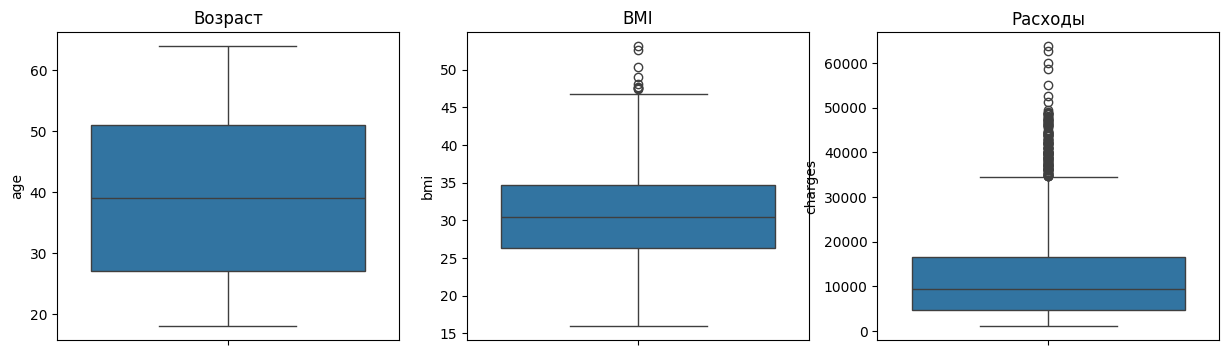

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['age'], ax=axes[0])
sns.boxplot(y=df['bmi'], ax=axes[1])
sns.boxplot(y=df['charges'], ax=axes[2])
axes[0].set_title('Возраст')
axes[1].set_title('ВМІ')
axes[2].set_title('Расходы')
plt.show()

В правом боксплоте мы видим что для большинства страховка стоит дешево, но так же есть значительная группа людей, которые платят аномально много. И это курящие люди с высоким BMI.

# Выводы

1. Переменная расходов имеет значительную ассиметрию
2. Курение это решающий фактор, что переводит клиента в совершенно другую ценовую категорию.
3. Индекс массы тела влияет на расходы не линейно. После BMI = 30 у курящих пациентов происходит резкий скачок в стоимости страховки
4. Возраст это самый стабильный признак и с ним расходы растут линейно
5. Пол, дети и регион это незначительные факторы
